# Подготовка к работе

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Описание полей

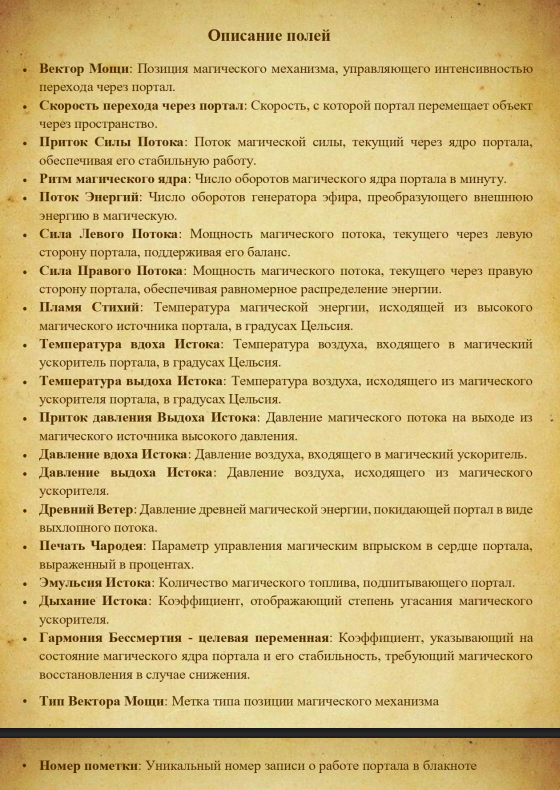




Загружаем датасет с данными о портальной деятельности

In [2]:
data = pd.read_csv('C:/tubaduba/practicum/data/portal_data.csv',encoding='cp1251',sep='|')

Датасет загружен, задача - регрессия, поскольку предсказываем признак Гармония Бессмертия

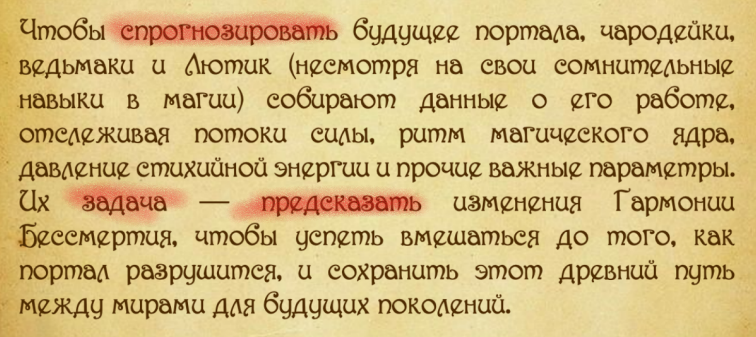

Согласно описанию признаков, определяем типы данных. Большинство здесь - физические величины, которые выражаются каким-нибудь числом, иногда с единицами измерения (могут понадобиться при добавлении или объединении признаков). Стоит отметить, что все, кроме двух признаков - вещественные. Это категориальный тип вектора мощи и целочисленный номер пометки



| **№** | Признак | Описание | Тип |
|---|---|---|---|
| | **Целевые признаки** | | |
| **1** | `Гармония Бессмертия` | Коэффициент, указывающий на состояние магического ядра портала и его стабильность | Вещественный(0;1) |
| | **Входные признаки** | | |
| **2** | `Вектор Мощи` | Позиция магического механизма, управляющего интенсивностью перехода через портал | Вещественный |
| **3** | `Скорость перехода через портал` | Скорость, с которой портал перемещает объект через пространство | Вещественный |
| **4** | `Приток Силы Потока` | Поток магической силы, текущий через ядро портала, обеспечивая стабильную работу | Вещественный |
| **5** | `Ритм магического ядра` | Число оборотов магического ядра портала в минуту | Вещественный |
| **6** | `Поток Энергий` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую | Вещественный |
| **7** | `Сила Левого Потока` | Мощность магического потока, текущего через левую сторону портала | Вещественный |
| **8** | `Сила Правого Потока` | Мощность магического потока, текущего через правую сторону портала | Вещественный |
| **9** | `Пламя Стихий` | Температура магической энергии, исходящей из высокого магического источника портала (°C) | Вещественный |
| **10** | `Температура вдоха Истока` | Температура воздуха, входящего в магический ускоритель портала (°C) | Вещественный |
| **11** | `Температура выдоха Истока` | Температура воздуха, исходящего из магического ускорителя портала (°C) | Вещественный |
| **12** | `Приток давления Выдоха Истока` | Давление магического потока на выходе из магического источника высокого давления | Вещественный |
| **13** | `Давление вдоха Истока` | Давление воздуха, входящего в магический ускоритель | Вещественный |
| **14** | `Давление выдоха Истока` | Давление воздуха, исходящего из магического ускорителя | Вещественный |
| **15** | `Древний Ветер` | Давление древней магической энергии, покидающей портал в виде выхлопного потока | Вещественный |
| **16** | `Печать Чародея` | Параметр управления магическим выбросом в сердце портала (%) | Вещественный(0;100) |
| **17** | `Эмульсия Истока` | Количество магического топлива, подпитывающего портал | Вещественный |
| **18** | `Дыхание Истока` | Коэффициент, отображающий степень угасания магического ускорителя | Вещественный |
| **19** | `Тип Вектора Мощи` | Метка типа позиции магического механизма | Категориальный |
| **20** | `Номер пометки` | Уникальный номер записи о работе портала | Целочисленный |

Номер пометки можно спокойно удалять - это просто индексы

In [3]:
data = data.drop(columns=['Номер пометки'])

Тип вектора мощи можно если что привести к численному значению (слабый - 1, средний - 2 и тд или как-то по-другому), но пока не буду

# Обработка данных

Сперва выведем некоторую информацию, чтобы удостовериться в правильности типов данных

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  11934 non-null  object 
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       11934 non-null  object 
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           11934 non-null  object 
 12  Давление выдоха Истока          

Видим, что Скорость перехода через портал, Температура вдоха Истока, Температура выдоха Истока, Давление вдоха Истока и Древний Ветер имеют неверный тип данных

Для Температуры вдоха Истока достаточно поменять тип даннных с целочисленного на вещественный, просто чтобы совпадало с другими признаками температуры



In [5]:
data["Температура вдоха Истока"] = data["Температура вдоха Истока"].astype("float64")

Для решения проблем с другими признаками выведем часть таблицы

In [6]:
data.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736.0,-,1.096,Не определено,5.947,-,7.137,0.082,0.95,0.975,Слабый
1,2.088,-,6960.180,144.111767,6828.469,28.204,28.204,635.401,736.0,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.6299600000000005,8379.229,145.220853,7111.811,60.358,60.358,606.002,736.0,-,1.389,Не определено,7.574,-,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736.0,-,1.658,Не определено,9.007,-,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.7166,21636.432,201.513586,8494.777,175.306,175.306,731.494,736.0,645.642,2.078,Не определено,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего


Видим, что у остальных признаков неправильно заполнены пропуски, чтобы поменять тип данных пока что заменим пропуски на NaN

In [7]:
for pryznac in ["Скорость перехода через портал","Температура выдоха Истока","Давление вдоха Истока","Древний Ветер"]:
    data[pryznac] = pd.to_numeric(data[pryznac], errors='coerce')

Проверим еще раз и убедимся что все правильно

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  float64
 9   Температура выдоха Истока       2387 non-null   float64
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           2439 non-null   float64
 12  Давление выдоха Истока          

Продолжим анализ с пропусков: выше где был вывод общей информации есть счетчик ненулевых значений.


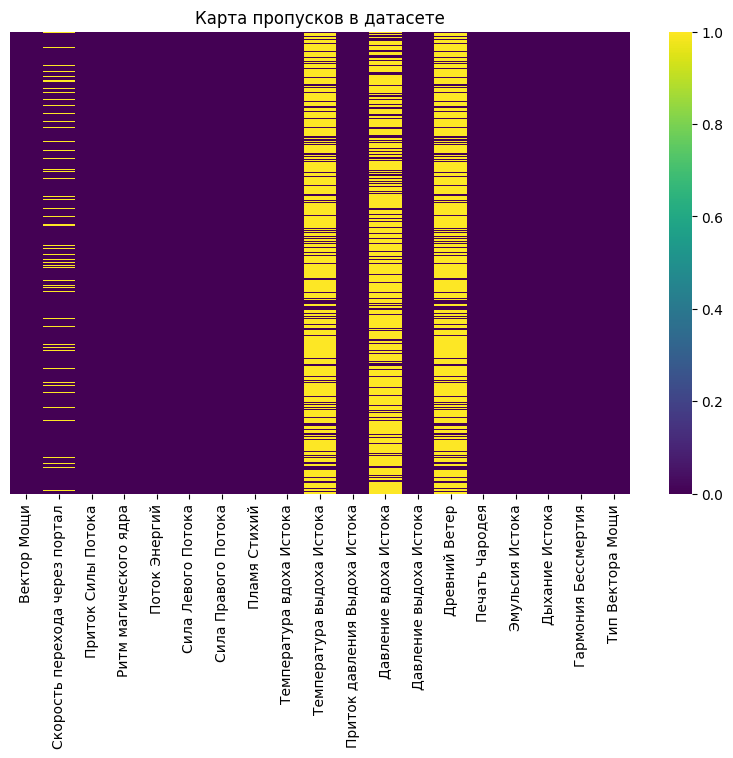

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков в датасете')
plt.show()


Для большинства признаков все значения на месте (11934 из 11934), для Скорости перехода через портал имеется около тысячи пропущенных значений (~10%), которые позже можно заполнить.

Также есть три признака, в которых отсутствует около 80% значений, мы эти признаки пожалуй выкинем.

In [24]:
data = data.drop(columns=['Температура выдоха Истока','Давление вдоха Истока','Древний Ветер'])